In [1]:
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --- PATHS ---
# Make sure you have added 'strangeralone/llvip-yolo' to your Kaggle data
base_llvip = '/kaggle/input/llvip-yolo/LLVIP/'
thermal_dir = '/kaggle/input/datasets/strangeralone/llvip-yolo/LLVIP-YOLO/test/lwir/images'
rgb_dir = '/kaggle/input/datasets/strangeralone/llvip-yolo/LLVIP-YOLO/test/visible/images'

# Get all .jpg files
thermal_files = sorted(glob.glob(os.path.join(thermal_dir, "*.jpg")))
rgb_files = sorted(glob.glob(os.path.join(rgb_dir, "*.jpg")))

# LLVIP uses identical names (e.g., 000001.jpg), so pairing is simple
thermal_names = {os.path.basename(f) for f in thermal_files}
rgb_names = {os.path.basename(f) for f in rgb_files}
common_names = sorted(list(thermal_names & rgb_names))

paired_thermal = [os.path.join(thermal_dir, name) for name in common_names]
paired_rgb = [os.path.join(rgb_dir, name) for name in common_names]

print(f"✅ LLVIP Ready! Found {len(paired_thermal)} perfectly aligned pairs.")

2026-03-13 05:37:33.255414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773380253.657492      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773380253.777205      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773380254.752775      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773380254.752810      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773380254.752813      24 computation_placer.cc:177] computation placer alr

✅ LLVIP Ready! Found 3463 perfectly aligned pairs.


In [2]:
import tensorflow as tf

# This disables the "Layout Optimizer" which is causing the Transpose error
tf.config.optimizer.set_experimental_options({'layout_optimizer': False})

print("Optimizer updated. You can now re-run the 'fit' cell.")

Optimizer updated. You can now re-run the 'fit' cell.


In [3]:
def load_images(t_path, r_path):
    # Load and process Infrared (Thermal)
    t_img = tf.io.read_file(t_path)
    t_img = tf.image.decode_jpeg(t_img, channels=3)
    t_img = tf.image.resize(t_img, [256, 256])
    t_img = (tf.cast(t_img, tf.float32) / 127.5) - 1.0

    # Load and process Visible (RGB)
    r_img = tf.io.read_file(r_path)
    r_img = tf.image.decode_jpeg(r_img, channels=3)
    r_img = tf.image.resize(r_img, [256, 256])
    r_img = (tf.cast(r_img, tf.float32) / 127.5) - 1.0

    return t_img, r_img

# Create the final Dataset
dataset = tf.data.Dataset.from_tensor_slices((paired_thermal, paired_rgb))
dataset = dataset.shuffle(buffer_size=1000).map(load_images).batch(1)

I0000 00:00:1773380295.054584      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1773380295.060334      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


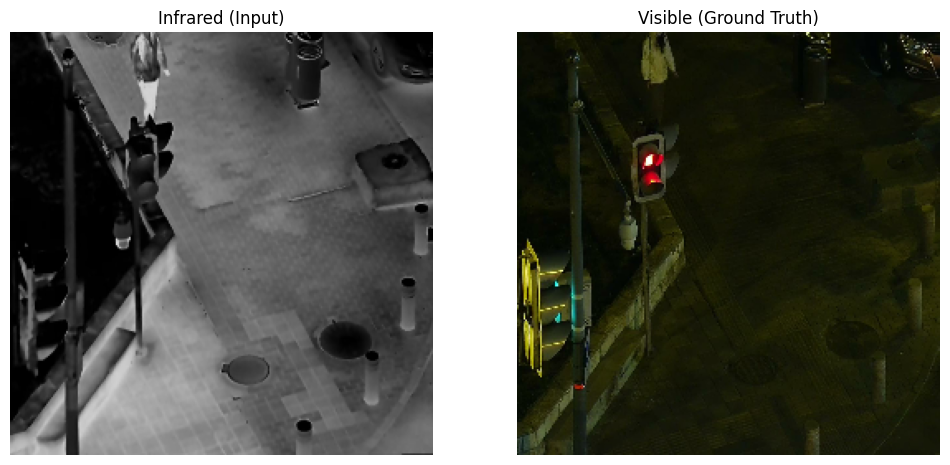

In [4]:
for x, y in dataset.take(1):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(x[0] * 0.5 + 0.5)
    plt.title("Infrared (Input)")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(y[0] * 0.5 + 0.5)
    plt.title("Visible (Ground Truth)")
    plt.axis('off')
    plt.show()

In [5]:
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(tf.keras.layers.BatchNormalization())
    result.add(tf.keras.layers.LeakyReLU())
    return result

def upsample(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(tf.keras.layers.Conv2DTranspose(filters, size, strides=2,
                                    padding='same', kernel_initializer=initializer,
                                    use_bias=False))
    result.add(tf.keras.layers.BatchNormalization())
    if apply_dropout:
        result.add(tf.keras.layers.Dropout(0.5))
    result.add(tf.keras.layers.ReLU())
    return result

def Generator():
    inputs = tf.keras.layers.Input(shape=[256, 256, 3])
    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (bs, 128, 128, 64)
        downsample(128, 4), # (bs, 64, 64, 128)
        downsample(256, 4), # (bs, 32, 32, 256)
        downsample(512, 4), # (bs, 16, 16, 512)
        downsample(512, 4), # (bs, 8, 8, 512)
        downsample(512, 4), # (bs, 4, 4, 512)
        downsample(512, 4), # (bs, 2, 2, 512)
        downsample(512, 4), # (bs, 1, 1, 512)
    ]
    up_stack = [
        upsample(512, 4, apply_dropout=True), # (bs, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 8, 8, 1024)
        upsample(512, 4), # (bs, 16, 16, 1024)
        upsample(256, 4), # (bs, 32, 32, 512)
        upsample(128, 4), # (bs, 64, 64, 256)
        upsample(64, 4), # (bs, 128, 128, 128)
    ]
    initializer = tf.random_normal_initializer(0., 0.02)
    last = tf.keras.layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                  kernel_initializer=initializer, activation='tanh')
    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
    skips = reversed(skips[:-1])
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = tf.keras.layers.Concatenate()([x, skip])
    return tf.keras.Model(inputs=inputs, outputs=last(x))

In [6]:
def Discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    inp = tf.keras.layers.Input(shape=[256, 256, 3], name='input_image')
    tar = tf.keras.layers.Input(shape=[256, 256, 3], name='target_image')
    x = tf.keras.layers.concatenate([inp, tar]) # (bs, 256, 256, channels*2)
    down1 = downsample(64, 4, False)(x) # (bs, 128, 128, 64)
    down2 = downsample(128, 4)(down1) # (bs, 64, 64, 128)
    down3 = downsample(256, 4)(down2) # (bs, 32, 32, 256)
    zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3) # (bs, 34, 34, 256)
    conv = tf.keras.layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer,
                         use_bias=False)(zero_pad1) # (bs, 31, 31, 512)
    batchnorm1 = tf.keras.layers.BatchNormalization()(conv)
    leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)
    zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu) # (bs, 33, 33, 512)
    last = tf.keras.layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2)
    return tf.keras.Model(inputs=[inp, tar], outputs=last)

In [7]:
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)
LAMBDA = 100

def generator_loss(disc_generated_output, gen_output, target):
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    # Mean Absolute Error (L1 Loss)
    l1_loss = tf.reduce_mean(tf.abs(target - gen_output))
    total_gen_loss = gan_loss + (LAMBDA * l1_loss)
    return total_gen_loss, gan_loss, l1_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + generated_loss

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

generator = Generator()
discriminator = Discriminator()

In [8]:
def generate_images(model, test_input, tar):
    prediction = model(test_input, training=True)
    plt.figure(figsize=(15, 15))
    display_list = [test_input[0], tar[0], prediction[0]]
    title = ['Input Infrared', 'Ground Truth', 'Predicted Image']
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(title[i])
        plt.imshow(display_list[i] * 0.5 + 0.5)
        plt.axis('off')
    plt.show()

@tf.function
def train_step(input_image, target, epoch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)
        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        gen_total_loss, gen_gan_loss, gen_l1_loss = generator_loss(disc_generated_output, gen_output, target)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    
    # CRITICAL: Return these values
    return gen_total_loss, disc_loss, gen_l1_loss

✅ Epoch 1 finished in 185.33 sec | L1 Loss: 0.1425
✅ Epoch 2 finished in 174.98 sec | L1 Loss: 0.1127
✅ Epoch 3 finished in 176.65 sec | L1 Loss: 0.1038
✅ Epoch 4 finished in 174.02 sec | L1 Loss: 0.1006
✅ Epoch 5 finished in 176.29 sec | L1 Loss: 0.0964
✅ Epoch 6 finished in 176.45 sec | L1 Loss: 0.0951
✅ Epoch 7 finished in 175.98 sec | L1 Loss: 0.0915
✅ Epoch 8 finished in 176.36 sec | L1 Loss: 0.0904
✅ Epoch 9 finished in 175.82 sec | L1 Loss: 0.0894
✅ Epoch 10 finished in 177.88 sec | L1 Loss: 0.0865
✅ Epoch 11 finished in 178.04 sec | L1 Loss: 0.0860
✅ Epoch 12 finished in 173.68 sec | L1 Loss: 0.0843
✅ Epoch 13 finished in 176.73 sec | L1 Loss: 0.0845
✅ Epoch 14 finished in 174.51 sec | L1 Loss: 0.0823
✅ Epoch 15 finished in 175.87 sec | L1 Loss: 0.0826
✅ Epoch 16 finished in 177.86 sec | L1 Loss: 0.0811
✅ Epoch 17 finished in 176.12 sec | L1 Loss: 0.0810
✅ Epoch 18 finished in 175.89 sec | L1 Loss: 0.0792
✅ Epoch 19 finished in 176.79 sec | L1 Loss: 0.0799
✅ Epoch 20 finished i

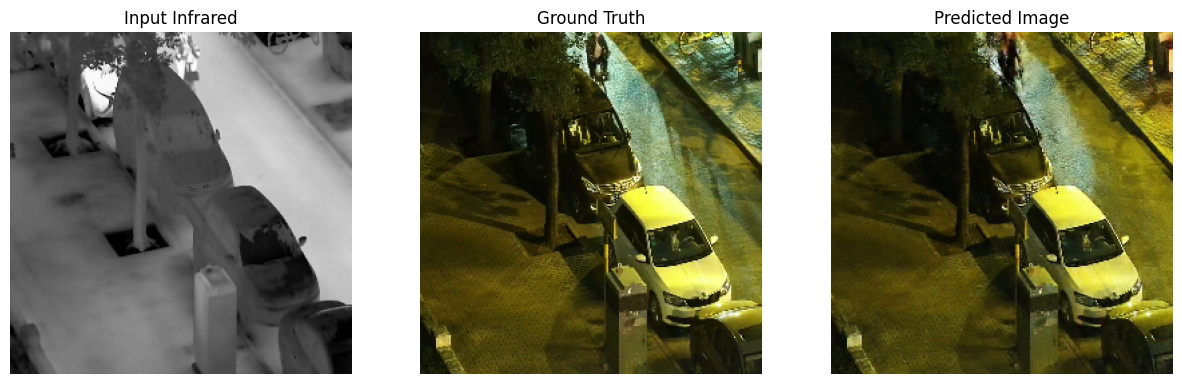

...............
✅ Epoch 100 finished in 175.16 sec | L1 Loss: 0.0709


In [9]:
from IPython import display as ipythondisplay # Use a unique name to avoid conflicts
import time
# Initialize history lists
time_history = []
gen_loss_log = []
disc_loss_log = []
l1_loss_log = []

def fit_final(train_ds, epochs):
    for epoch in range(epochs):
        start = time.time()
        
        epoch_gen_losses = []
        epoch_disc_losses = []
        epoch_l1_losses = []
        
        # Use the unique name here
        ipythondisplay.clear_output(wait=True)
        
        for t in time_history:
            print(t)
            
        print(f"\n--- Starting Epoch {epoch+1}/{epochs} ---")
        
        for example_input, example_target in train_ds.take(1):
            generate_images(generator, example_input, example_target)
            
        for n, (input_image, target) in train_ds.enumerate():
            g_loss, d_loss, l1 = train_step(input_image, target, epoch)
            
            epoch_gen_losses.append(g_loss)
            epoch_disc_losses.append(d_loss)
            epoch_l1_losses.append(l1)
            
            if (n+1) % 100 == 0:
                print('.', end='', flush=True)
        
        # Calculate averages and store
        gen_loss_log.append(np.mean(epoch_gen_losses))
        disc_loss_log.append(np.mean(epoch_disc_losses))
        l1_loss_log.append(np.mean(epoch_l1_losses))
        
        epoch_time = time.time() - start
        time_msg = f'✅ Epoch {epoch+1} finished in {epoch_time:.2f} sec | L1 Loss: {l1_loss_log[-1]:.4f}'
        time_history.append(time_msg)
        print(f'\n{time_msg}')

# Run again
fast_dataset = dataset.take(1500) 
fit_final(fast_dataset, 100)

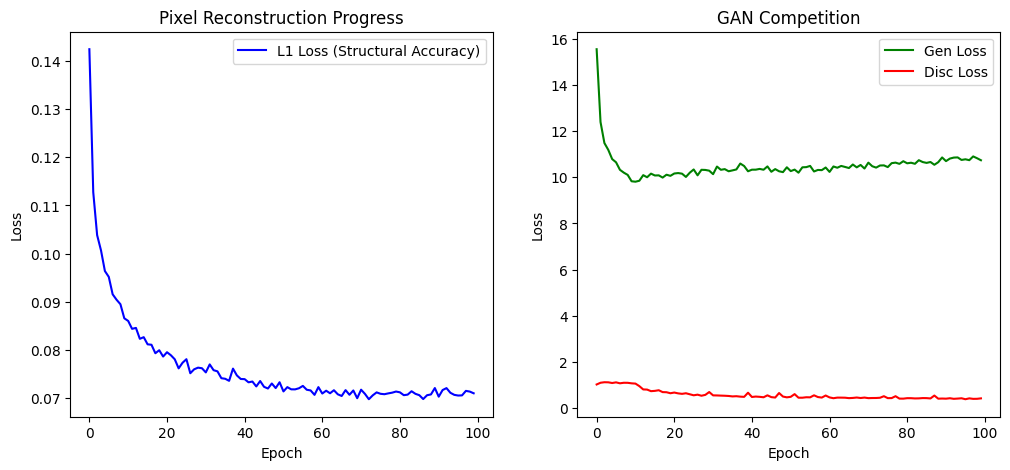

In [10]:
import matplotlib.pyplot as plt

def plot_history():
    plt.figure(figsize=(12, 5))
    
    # Plot L1 Loss (The most important for pixel accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(l1_loss_log, label='L1 Loss (Structural Accuracy)', color='blue')
    plt.title('Pixel Reconstruction Progress')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot GAN losses
    plt.subplot(1, 2, 2)
    plt.plot(gen_loss_log, label='Gen Loss', color='green')
    plt.plot(disc_loss_log, label='Disc Loss', color='red')
    plt.title('GAN Competition')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

plot_history()

In [11]:
# Save the generator architecture and weights together
generator.save('pix2pix_llvip_generator.h5')
print("✅ Model saved to /kaggle/working/pix2pix_llvip_generator.h5")

✅ Model saved to /kaggle/working/pix2pix_llvip_generator.h5


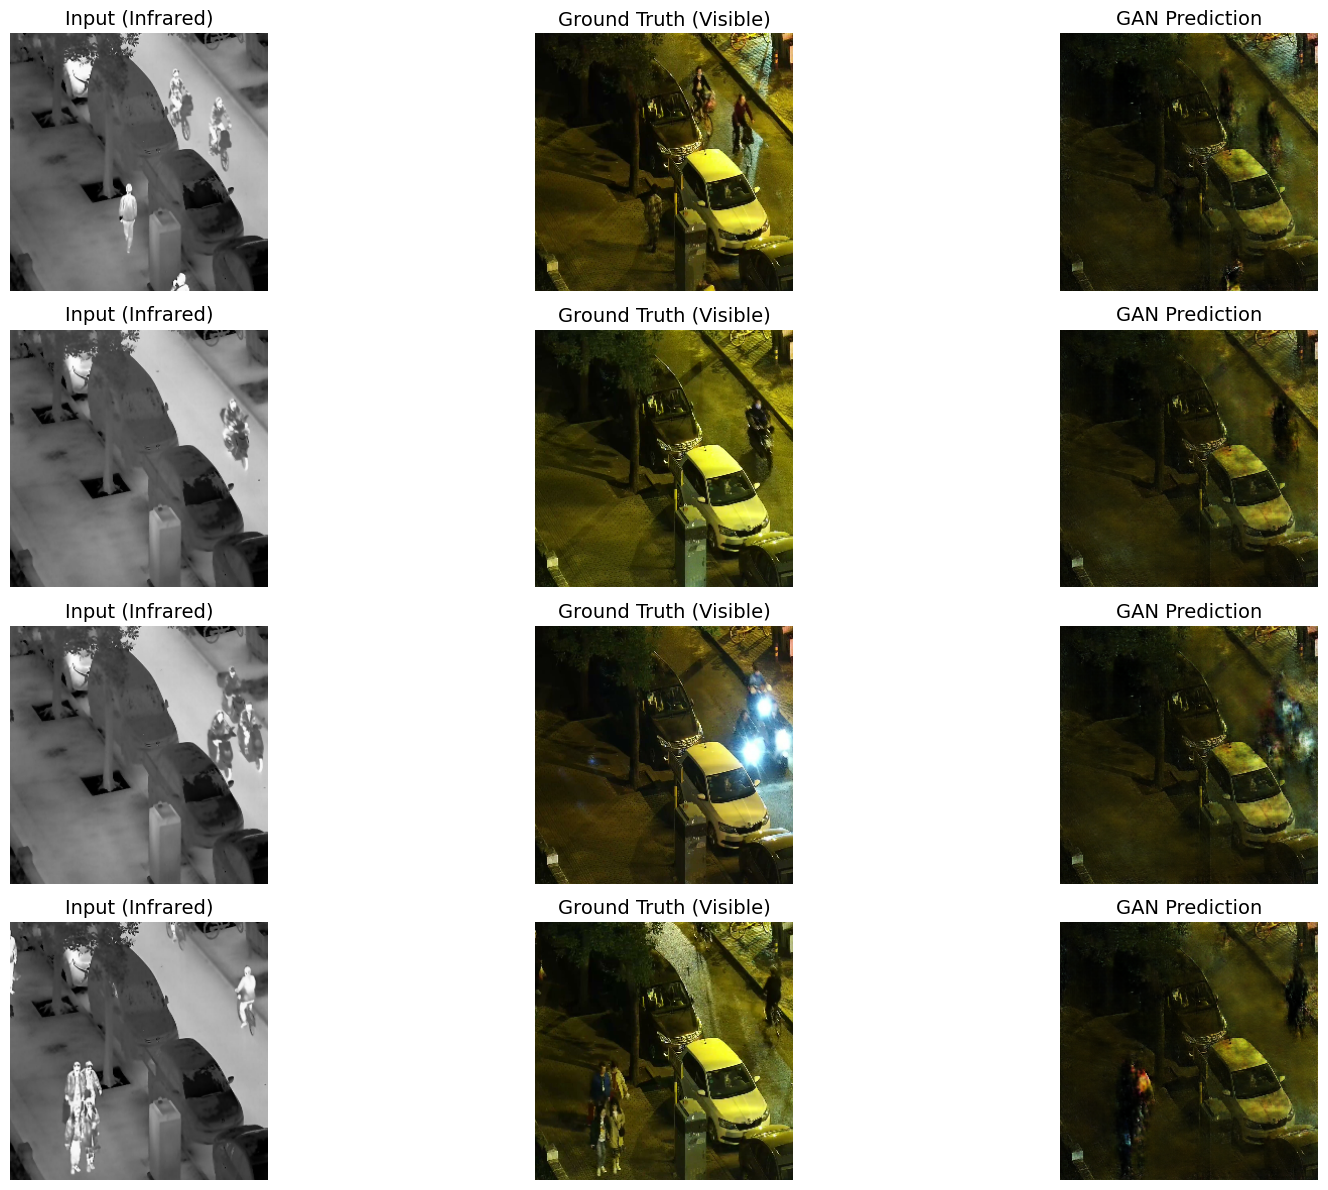

In [12]:
import matplotlib.pyplot as plt

def plot_test_results(dataset, model, num_images=4):
    # Set the figure size
    plt.figure(figsize=(18, 12))
    
    # Take a batch of images from the dataset
    for i, (inp, tar) in enumerate(dataset.take(num_images)):
        # Generate the prediction (ensure training=False for inference mode)
        prediction = model(inp, training=False)
        
        # Prepare the images for display (Denormalize from [-1, 1] to [0, 1])
        display_list = [inp[0], tar[0], prediction[0]]
        titles = ['Input (Infrared)', 'Ground Truth (Visible)', 'GAN Prediction']
        
        for j in range(3):
            plt.subplot(num_images, 3, i*3 + j + 1)
            plt.title(titles[j], fontsize=14)
            # Standard normalization for imshow
            plt.imshow(display_list[j] * 0.5 + 0.5)
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

# Run this to see your final results
plot_test_results(dataset, generator)